In [1]:
import sys
sys.path.insert(0, '..')

from datetime import datetime
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.ticker as mtick
import seaborn as sns
import requests
import time
import re

from src.data import (
    load_and_prepare, get_username_mappings,
    load_standings, load_model_predictions,
)
from src.simulation import (
    build_player_pool, build_player_pool_score,
    run_simulation, run_simulation_score, build_results,
)
from src.portfolio import (
    build_portfolio, run_portfolio_mc, run_portfolio_mc_score, pnl_summary,
    run_payoff_matrix, portfolio_kelly,
    compute_hedge_correlations, show_best_hedges, kalshi_order_price,
)

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
pd.set_option('display.max_rows', 300)
pd.set_option('display.max_columns', 300)
pd.set_option('display.max_colwidth', 300)

USERNAME_TO_PLAYER, PLAYER_TO_USERNAME = get_username_mappings()
df_standings = load_standings()

_results_raw = load_model_predictions().set_index('username')
for _n in [1, 3, 5, 8, 10]:
    _results_raw[f'P_top{_n}'] = _results_raw['p_participate'] * _results_raw[f'P_top{_n}_given_play']
    _results_raw[f'ip_adv_top{_n}'] = _results_raw[f'P_top{_n}_given_play'] / _results_raw[f'P_top{_n}']
results = _results_raw

In [3]:
BASE = "https://api.elections.kalshi.com/trade-api/v2"
event_tickers = ["KXTITLEDTUESDAY-26JUL28","KXTITLEDTUESTOP-26JUL28T3","KXTITLEDTUESTOP-26JUL28T5","KXTITLEDTUESTOP-26JUL28T8"]


markets = []
cursor = None
for event_ticker in event_tickers:
    while True:
        params = {"event_ticker": event_ticker, "status": "open", "limit": 200}
        if cursor:
            params["cursor"] = cursor
        resp = requests.get(f"{BASE}/markets", params=params)
        resp.raise_for_status()
        data = resp.json()
        markets.extend(data.get("markets", []))
        cursor = data.get("cursor")
        if not cursor:
            break

all_asks= []
all_players = []

if markets:
    print(f"Found {len(markets)} markets in events '{[event_ticker for event_ticker in event_tickers]}'. Fetching rates...")

    for market in markets:
        ticker = market["ticker"]
        title = market.get("title", "")
        subtitle = market.get("yes_sub_title", "")
        all_players.append(subtitle)

        ob_resp = requests.get(f"{BASE}/markets/{ticker}/orderbook")

        if ob_resp.status_code == 200:
            ob = ob_resp.json().get("orderbook_fp") or {}
            # Resting NO bids: each [price, qty] NO bid implies
            # YES is for sale at (1.00 - no_price) for that quantity.
            yes_levels = ob.get("yes_dollars") or []
            no_levels = ob.get("no_dollars") or []

            for price_str, qty_str in yes_levels:
                no_ask = float("1.00") - float(price_str)
                all_asks.append({
                    "Market Ticker": ticker,
                    "Market Title": title,
                    "Player Name": subtitle,
                    "Ask Price ($)": float(no_ask),
                    "Quantity Available": float(qty_str),
                    "Side": "NO"
                })
            for price_str, qty_str in no_levels:
                yes_ask = float("1.00") - float(price_str)
                all_asks.append({
                    "Market Ticker": ticker,
                    "Market Title": title,
                    "Player Name": subtitle,
                    "Ask Price ($)": float(yes_ask),
                    "Quantity Available": float(qty_str),
                    "Side": "YES"
                })
        else:
            print(f"Could not retrieve orderbook for {ticker} "
                  f"(HTTP {ob_resp.status_code})")

        time.sleep(0.05)  # stay under public rate limits


def kalshi_order_price(ask_price):
    return ask_price + (0.07 * ask_price * (1.0 - ask_price))

Found 216 markets in events '['KXTITLEDTUESDAY-26JUL28', 'KXTITLEDTUESTOP-26JUL28T3', 'KXTITLEDTUESTOP-26JUL28T5', 'KXTITLEDTUESTOP-26JUL28T8']'. Fetching rates...


In [4]:
df = pd.DataFrame(all_asks)
df['n'] = df['Market Title'].apply(lambda s: re.search(r'\d+',s).group())

df['username'] = df['Player Name'].apply(lambda n: PLAYER_TO_USERNAME[n])
evs = []
for _, row in df.iterrows():
    n = 1 if row['n'] == '28' else int(row['n'])
    p_yes = (results.loc[row['username'], f'P_top{n}'].item())
    evs.append(p_yes if row['Side']=='YES' else (1-p_yes))

df['EV'] = evs
df['Order Price'] = (df['Ask Price ($)'] + 0.07 * df['Ask Price ($)'] * (1.0 - df['Ask Price ($)']))
df['Total Cost'] = df['Quantity Available']*df['Order Price']
df['Expected Return'] = ((df['EV']-df['Order Price'])*df['Quantity Available'].astype(int))
df['ROI'] = round(df['EV']/df['Order Price'].astype(float),3)
df = df[df['ROI']>1.]
print(df['Expected Return'].sum())
df[['Market Title','ROI','Side','Order Price','EV','Quantity Available','Total Cost','Expected Return']][(df['ROI']>1.)].sort_values('ROI',ascending=False)

683.8158124898216


,Market Title,ROI,Side,Order Price,EV,Quantity Available,Total Cost,Expected Return
1198,"Will Maxime Vachier-Lagrave finish top 3 in the Titled Tuesday chess competition on Jul 28, 2026?",1.739,YES,0.042688,0.074218,108.50,4.631648,3.405217
1653,"Will Aleksei Sarana finish top 3 in the Titled Tuesday chess competition on Jul 28, 2026?",1.365,YES,0.148428,0.202669,100.00,14.842800,5.424059
3139,"Will Magnus Carlsen finish top 8 in the Titled Tuesday chess competition on Jul 28, 2026?",1.355,NO,0.606933,0.822432,20.00,12.138660,4.309982
2586,"Will Aleksei Sarana finish top 5 in the Titled Tuesday chess competition on Jul 28, 2026?",1.353,YES,0.232012,0.313802,131.00,30.393572,10.714533
2038,"Will Parham Maghsoodloo finish top 5 in the Titled Tuesday chess competition on Jul 28, 2026?",1.348,YES,0.127392,0.171775,100.00,12.739200,4.438280
3138,"Will Magnus Carlsen finish top 8 in the Titled Tuesday chess competition on Jul 28, 2026?",1.333,NO,0.616800,0.822432,100.00,61.680000,20.563211
2697,"Will Zhamsaran Tsydypov finish top 8 in the Titled Tuesday chess competition on Jul 28, 2026?",1.311,YES,0.158925,0.208347,100.00,15.892500,4.942232
1008,"Will Sina Movahed finish top 3 in the Titled Tuesday chess competition on Jul 28, 2026?",1.300,YES,0.116853,0.151965,100.00,11.685300,3.511225
2585,"Will Aleksei Sarana finish top 5 in the Titled Tuesday chess competition on Jul 28, 2026?",1.295,YES,0.242397,0.313802,100.00,24.239700,7.140533
3137,"Will Magnus Carlsen finish top 8 in the Titled Tuesday chess competition on Jul 28, 2026?",1.292,NO,0.636492,0.822432,200.00,127.298400,37.188021


In [3]:
all_players = list(set(all_players))
cols = [f'P_top{n}' for n in [1,3,5,8]]
df = (results[results.index.isin([PLAYER_TO_USERNAME[p] for p in all_players])][cols]*100).reset_index()
df['name'] = df['username'].apply(lambda n: USERNAME_TO_PLAYER[n])
cols.insert(0,'name')
df[cols].sort_values('name').set_index('name').round(1)

,P_top1,P_top3,P_top5,P_top8
name,,,,
Aleksandar Indjic,1.2,2.6,3.7,6.4
Aleksandr Shimanov,0.2,1.7,3.6,5.7
Aleksei Sarana,7.3,20.3,31.4,43.7
Alexander Grischuk,0.9,4.6,9.8,16.6
Andrey Esipenko,0.1,0.8,1.5,2.4
Aravindh Chithambaram,0.1,0.6,1.8,4.6
Arjun Erigaisi,3.4,13.4,21.8,29.8
Bardiya Daneshvar,0.1,1.1,4.2,10.1
Benjamin Bok,0.4,2.0,4.1,7.1


In [6]:
# ── Simple (single-bet) Kelly sizing ─────────────────────────────────────────
# f* = (p - c) / (1 - c)  where p = model probability, c = cost per share
# Applied independently per position then normalised if total > 1.
# Use KELLY_MULT < 1 (half-Kelly = 0.5 recommended) to account for model error.

BANKROLL   = 2000   # <-- set to your actual bankroll in $
KELLY_MULT = 0.5    # half-Kelly

df_pos = df[df['ROI'] > 1.0].copy()

# Raw single-bet Kelly fraction: optimal bankroll fraction if this were the only bet
df_pos['kelly_f'] = (df_pos['EV'] - df_pos['Order Price']) / (1.0 - df_pos['Order Price'])

# If the sum of independent Kelly fractions exceeds 1, the positions collectively
# need more than the full bankroll.  Normalise proportionally as a conservative
# approximation for correlated simultaneous bets.
total_f = df_pos['kelly_f'].sum()
if total_f > 1.0:
    print(f"Sum of single-bet Kelly fractions = {total_f:.2f} — normalising to 1.0")
    df_pos['kelly_f'] /= total_f

# alloc_frac: final fraction of bankroll deployed to each position
# = normalised kelly_f * KELLY_MULT
df_pos['alloc_frac']   = df_pos['kelly_f'] * KELLY_MULT
df_pos['kelly_shares'] = (df_pos['alloc_frac'] * BANKROLL / df_pos['Order Price']).round().clip(lower=0).astype(int)
df_pos['kelly_cost']   = df_pos['kelly_shares'] * df_pos['Order Price']
df_pos['kelly_ev']     = df_pos['kelly_shares'] * df_pos['EV']
df_pos['kelly_edge']   = df_pos['kelly_ev'] - df_pos['kelly_cost']

df_kelly = df_pos[df_pos['kelly_shares'] > 0].copy()

total_cost = df_kelly['kelly_cost'].sum()
total_ev   = df_kelly['kelly_ev'].sum()
print(f"Bankroll ${BANKROLL:,.0f}  |  Exposure ${total_cost:.0f} ({total_cost/BANKROLL*100:.1f}%)  |  "
      f"Expected edge ${total_ev - total_cost:.2f}  |  Portfolio ROI {(total_ev/total_cost - 1)*100:.1f}%\n")

df_kelly[['Market Title', 'Side', 'ROI', 'Order Price', 'EV', 'kelly_f', 'alloc_frac', 'kelly_shares', 'kelly_cost', 'kelly_edge']]\
    .sort_values('kelly_f', ascending=False)\
    .style.format({'Order Price': '{:.3f}', 'EV': '{:.3f}', 'kelly_f': '{:.4f}', 'alloc_frac': '{:.4f}',
                   'kelly_cost': '${:.2f}', 'kelly_edge': '${:.2f}'})

Sum of single-bet Kelly fractions = 57.28 — normalising to 1.0
Bankroll $2,000  |  Exposure $1001 (50.1%)  |  Expected edge $51.23  |  Portfolio ROI 5.1%



,Market Title,Side,ROI,Order Price,EV,kelly_f,alloc_frac,kelly_shares,kelly_cost,kelly_edge
340,"Will Hikaru Nakamura win the Titled Tuesday weekly chess competition, originally scheduled for Jul 28, 2026 at 11:00am EDT?",NO,1.049000,0.953,1.000,0.0175,0.0087,18,$17.16,$0.84
339,"Will Hikaru Nakamura win the Titled Tuesday weekly chess competition, originally scheduled for Jul 28, 2026 at 11:00am EDT?",NO,1.009000,0.991,1.000,0.0175,0.0087,18,$17.83,$0.17
341,"Will Hikaru Nakamura win the Titled Tuesday weekly chess competition, originally scheduled for Jul 28, 2026 at 11:00am EDT?",NO,1.059000,0.944,1.000,0.0175,0.0087,18,$16.99,$1.01
753,"Will Javokhir Sindarov finish top 3 in the Titled Tuesday chess competition on Jul 28, 2026?",NO,1.019000,0.981,1.000,0.0175,0.0087,18,$17.66,$0.34
754,"Will Javokhir Sindarov finish top 3 in the Titled Tuesday chess competition on Jul 28, 2026?",NO,1.029000,0.972,1.000,0.0175,0.0087,18,$17.50,$0.50
695,"Will Nodirbek Abdusattorov finish top 3 in the Titled Tuesday chess competition on Jul 28, 2026?",NO,1.009000,0.991,1.000,0.0175,0.0087,18,$17.83,$0.17
1238,"Will Hikaru Nakamura finish top 5 in the Titled Tuesday chess competition on Jul 28, 2026?",NO,1.029000,0.972,1.000,0.0175,0.0087,18,$17.50,$0.50
1239,"Will Hikaru Nakamura finish top 5 in the Titled Tuesday chess competition on Jul 28, 2026?",NO,1.039000,0.963,1.000,0.0175,0.0087,18,$17.33,$0.67
958,"Will Wesley So finish top 5 in the Titled Tuesday chess competition on Jul 28, 2026?",NO,1.009000,0.991,1.000,0.0175,0.0087,18,$17.83,$0.17
959,"Will Wesley So finish top 5 in the Titled Tuesday chess competition on Jul 28, 2026?",NO,1.019000,0.981,1.000,0.0175,0.0087,18,$17.66,$0.34


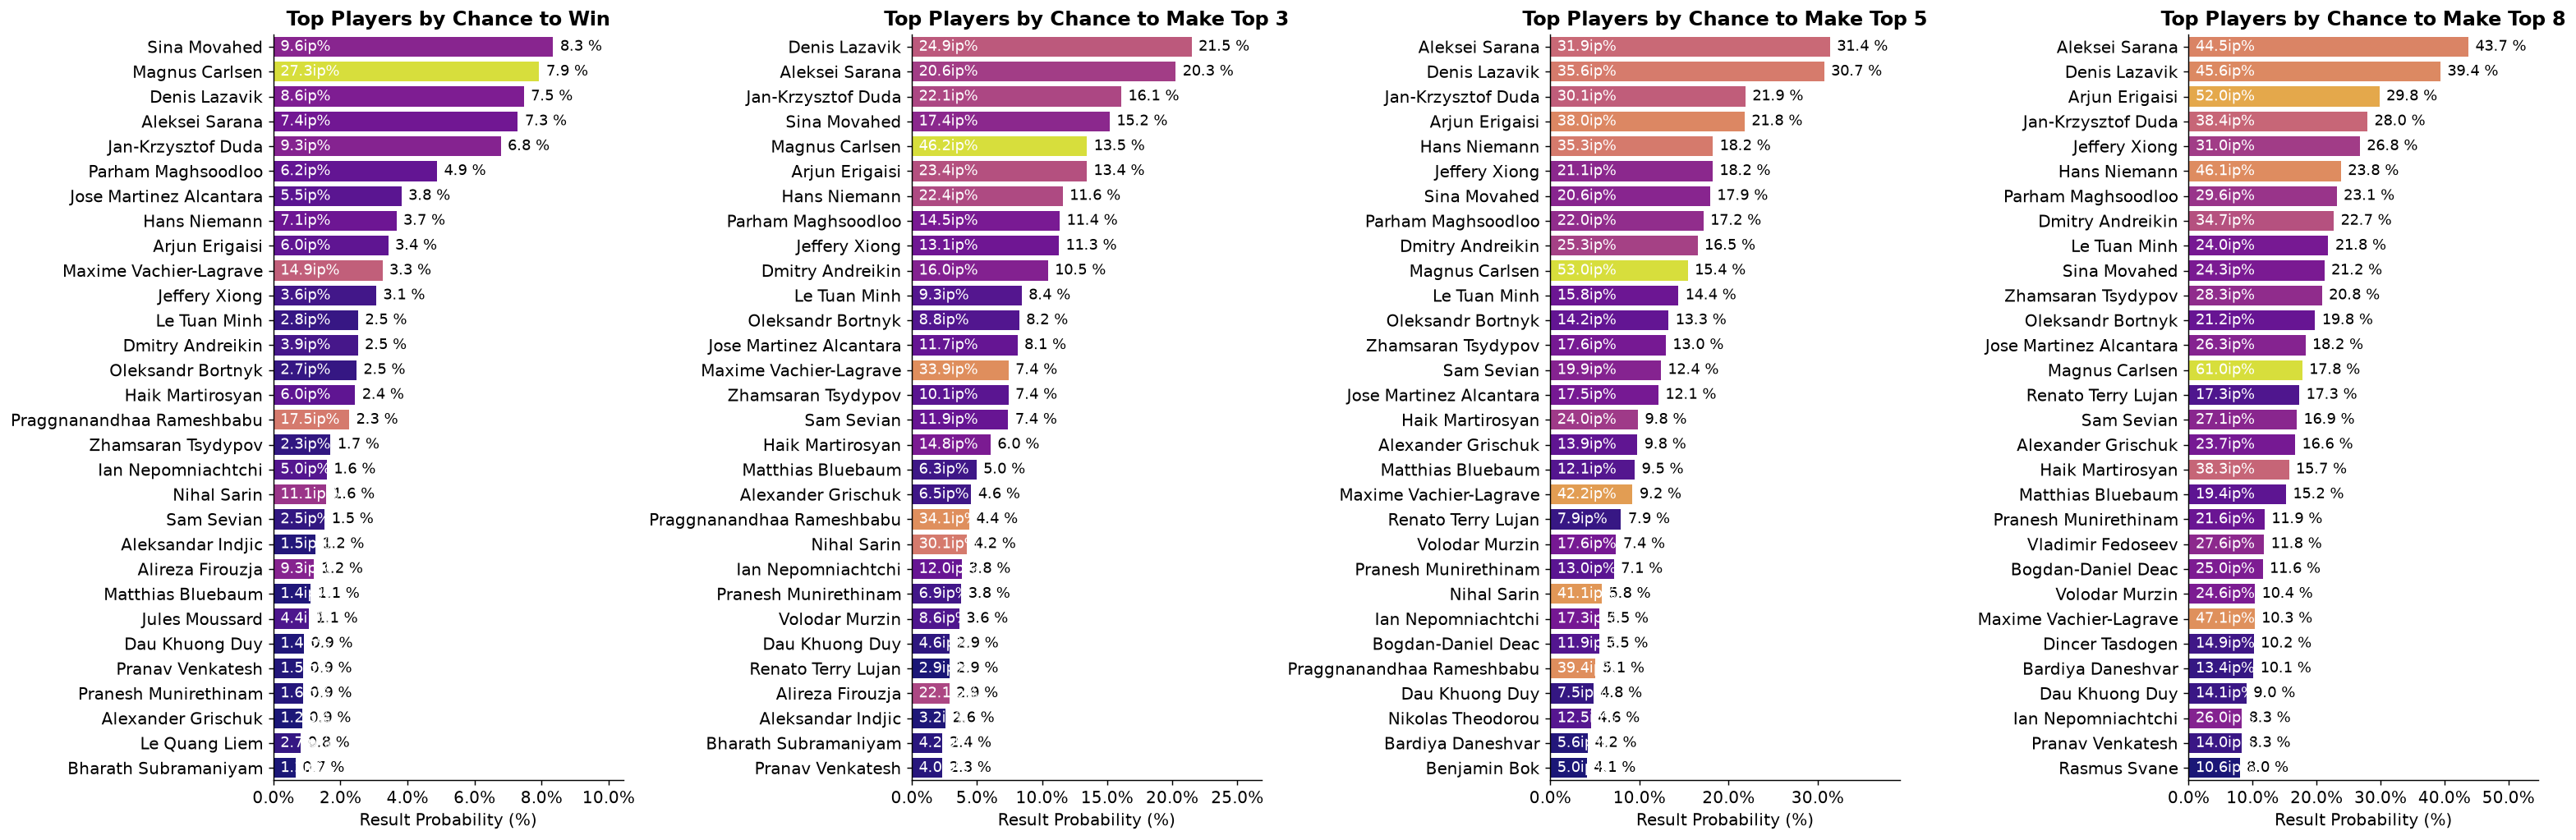

In [17]:
fig, axes = plt.subplots(1,4, figsize=(24,8))

metrics = [
    (1,'Top Players by Chance to Win'),
    (3,'Top Players by Chance to Make Top 3'),
    (5,'Top Players by Chance to Make Top 5'),
    (8,'Top Players by Chance to Make Top 8'),
]

cmap = plt.get_cmap('plasma')

for ax, (n, title) in zip(axes, metrics):

    col_chance = f'P_top{n}'
    col_when = f'P_top{n}_given_play'

    df_plot = results.nlargest(30,col_chance).reset_index()

    norm = mcolors.Normalize(vmin=df_plot[col_when].min(), vmax=df_plot[col_when].max())
    colors = cmap(norm(df_plot[col_when]))

    names = [USERNAME_TO_PLAYER.get(username,username) for username in df_plot['username']]

    sns.barplot(data = df_plot, x=col_chance, y=names, ax=ax, palette=colors)

    ax.set_title(title, fontweight='bold')

    max_width = df_plot[col_chance].max()*1.25
    ax.set_xlim(0, max_width)
    ax.set_xlabel('Result Probability (%)')
    ax.set_ylabel('')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))

    for i, p in enumerate(ax.patches):
        width = p.get_width()
        y = p.get_y() + p.get_height()/2
        
        chance_val = df_plot.iloc[i][col_chance]
        when_val = df_plot.iloc[i][col_when]

        ax.text(width + (max_width * 0.02), y, f'{chance_val*100:.1f} %', va = 'center', ha='left', fontsize=10, color='black')
        ax.text(max_width * 0.02, y, f'{when_val*100:.1f}ip%', va = 'center', ha='left', fontsize=10, color='white')

plt.tight_layout()
plt.show()

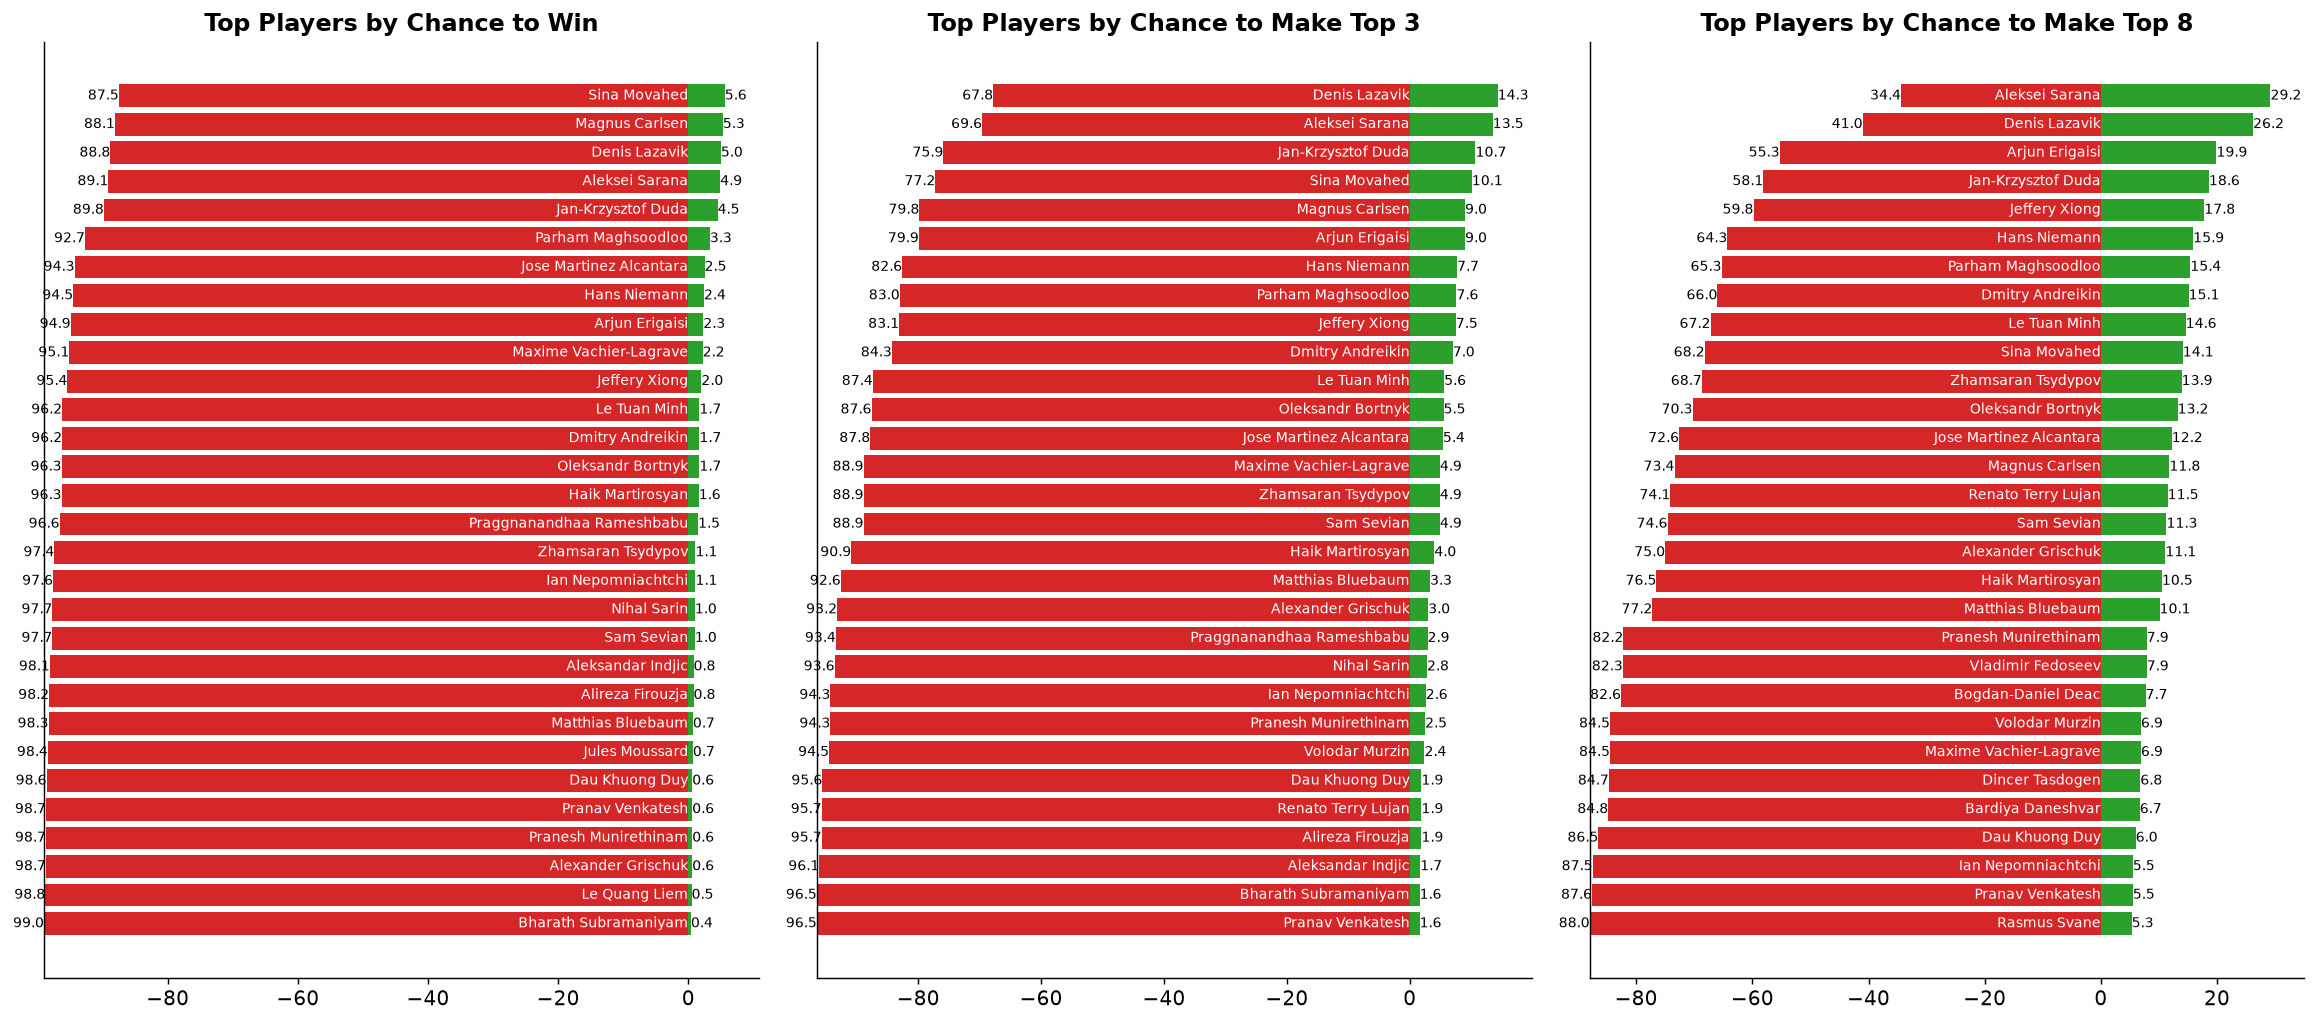

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18,8))

metrics = [
    (1,'Top Players by Chance to Win'),
    (3,'Top Players by Chance to Make Top 3'),
    (8,'Top Players by Chance to Make Top 8'),
]

cmap = plt.get_cmap('plasma')

for ax, (n, title) in zip(axes, metrics):

    col_chance = f'P_top{n}'
    col_when = f'P_top{n}_given_play'

    df_plot = results.nlargest(30,col_chance).reset_index()

    # Calculate Kalshi Yes and No prices
    # Using np.clip to ensure the No price doesn't drop below $0.00 if the estimate is very high (>75%)
    df_plot['Yes_Price'] = np.round(df_plot[col_chance] * (2/3) * 100, 1)
    df_plot['No_Price'] = np.round((1-df_plot[col_chance] * (3/2))*100, 1)

    # --- Plot YES Bars ---
    ax.barh(df_plot.index, df_plot['Yes_Price'], height=0.8, color='#2ca02c', label='Yes Price')

    # --- Plot NO Bars ---
    ax.barh(df_plot.index, df_plot['No_Price'], left=-df_plot['No_Price'], height=0.8, color='#d62728', label='No Price')

    # Set the Y-axis labels to the Yes Price
    ax.set_yticks([])
    ax.invert_yaxis()  # Put the highest chance player at the top
    ax.set_title(title, fontweight='bold')

    
    # Add data labels dynamically
    for i, row in df_plot.iterrows():
        yes_val = row['Yes_Price']
        no_val = row['No_Price']
        name = USERNAME_TO_PLAYER.get(row['username'],row['username'])
        
        # Text for the Yes price (placed slightly to the right of the green bar's edge)
        ax.text(yes_val, i, yes_val, va='center', ha='left', fontsize=8, color='black')
        
        # Text for the No price (placed slightly to the left of the red bar's edge)
        # The inner edge of the red bar is exactly at (1 - no_val)
        ax.text(-no_val, i, no_val, va='center', ha='right', fontsize=8, color='black')

        ax.text(0, i, name, va='center', ha='right', fontsize=8, color='white')



plt.tight_layout()
plt.show()

findfont: Failed to find font weight heavy, now using 700.


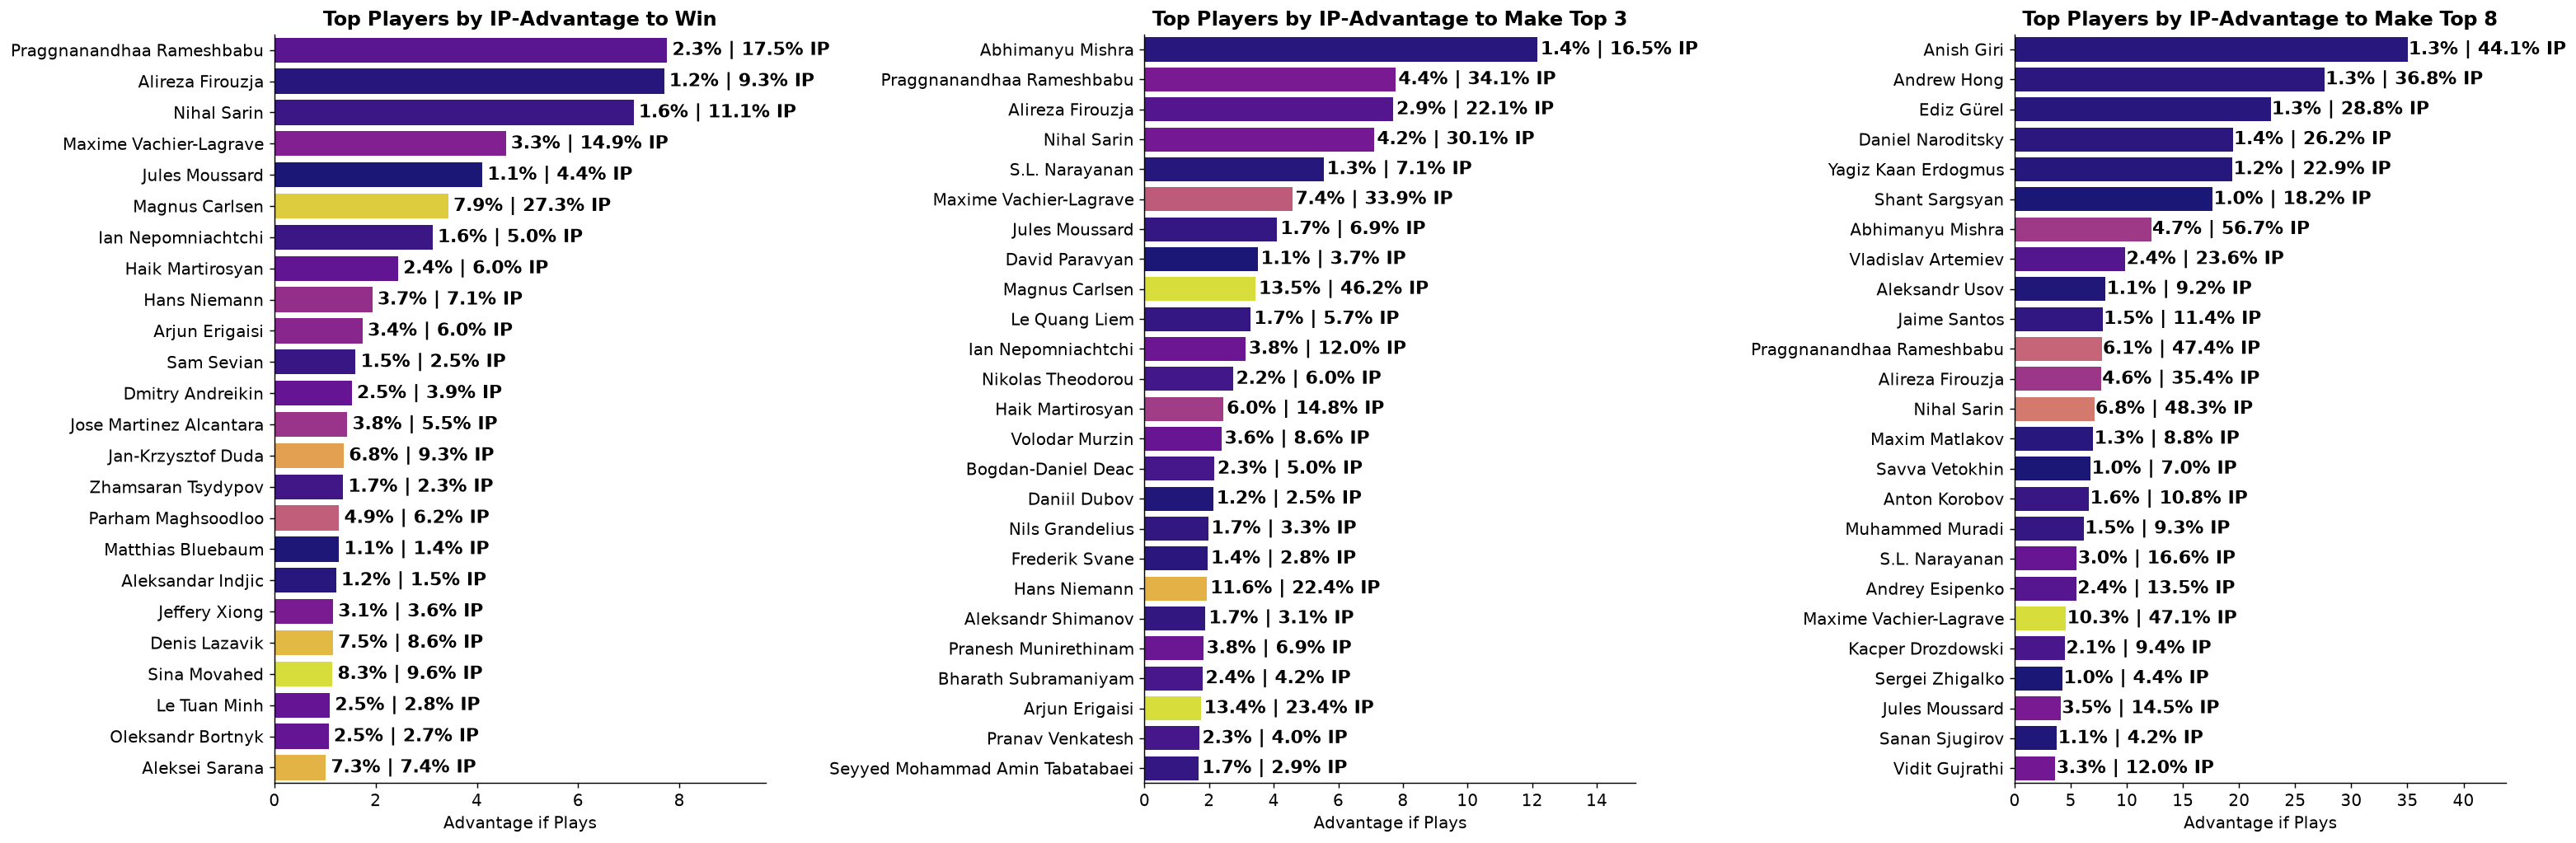

In [9]:
fig, axes = plt.subplots(1,3, figsize=(24,8))

metrics = [
    (1,'Top Players by IP-Advantage to Win'),
    (3,'Top Players by IP-Advantage to Make Top 3'),
    (8,'Top Players by IP-Advantage to Make Top 8'),
]

cmap = plt.get_cmap('plasma')

for ax, (n, title) in zip(axes, metrics):

    col_when = f'P_top{n}'
    col_chance = f'P_top{n}_given_play'
    ip_adv = f'ip_adv_top{n}'

    df_plot = results[results[col_when]>.01].nlargest(25,ip_adv).reset_index()

    def get_name(username):
        try:
            return USERNAME_TO_PLAYER[username]
        except:
            print(username, "?")
            return username
    df_plot['name'] = df_plot['username'].apply(get_name)

    norm = mcolors.Normalize(vmin=df_plot[col_when].min(), vmax=df_plot[col_when].max())
    colors = cmap(norm(df_plot[col_when]))

    sns.barplot(data = df_plot, x=ip_adv, y='name', ax=ax, palette=colors)

    ax.set_title(title, fontweight='bold')

    max_width = df_plot[ip_adv].max()*1.25
    ax.set_xlim(0, max_width)
    ax.set_xlabel('Advantage if Plays')
    ax.set_ylabel('')

    for i, p in enumerate(ax.patches):
        width = p.get_width()
        y = p.get_y() + p.get_height()/2
        
        chance_val = df_plot.iloc[i][col_chance]
        when_val = df_plot.iloc[i][col_when]
        adv_val = df_plot.iloc[i][ip_adv]
        name = df_plot.iloc[i]['name']

        ax.text(adv_val+0.1, y, f'{when_val*100:.1f}% | {chance_val*100:.1f}% IP', va = 'center', ha='left', fontsize=12, color='black', fontweight='heavy')

plt.tight_layout()
plt.show()

In [10]:
def display_profits(df_tt, df_results, verbose=False):
    costs = 0
    revenue = 0
    for idx, row in df_tt.iterrows():
        costs += row['cost']

        pos = 1.0 if row['position']=='Yes' else 0.0
        username = PLAYER_TO_USERNAME[row['marketTitle']]
        n = row['n']

        if not username in df_results.index:
            if verbose:
                print(f"{row['marketTitle']} in top {n}: -${row['cost']}")
            continue

        result = df_results.loc[username, f'P_top{n}'].item()

        if result == pos:
            if verbose:
                print(f"{row['marketTitle']} in top {n}: {'YES' if result > 0 else 'NO'}. +${row['volume'] - row['cost']}")
            revenue += row['volume']
        else:
            if verbose:
                print(f"{row['marketTitle']} in top {n}: {'YES' if result > 0 else 'NO'}. -${row['cost']}")
    
    return revenue - costs

def avg_profits(df, df_results, fees=0, verbose=False):
    revenues = []
    costs = []
    values = []
    values_per_share = []
    for idx, row in df.iterrows():
        username = PLAYER_TO_USERNAME[row['marketTitle']]
        n = row['n']
        costs.append(round(row['volume']*row['orderPrice'],2))

        if not username in df_results.index:
            print(f"{row['marketTitle']} in top {n}\t\t{row['position'].upper()}:\tBought {row['volume']} @{row['orderPrice']:.2f}.\t0.0 EV per share.\t ${-row['cost']:.2f} EV\t {0:.2f}% ROI")
            revenues.append(0)
            continue

        result = df_results.loc[username, f'P_top{n}'].item()
        value = result if row['position']=='Yes' else (1-result)
        revenues.append(row['volume']*value)
        values.append(f'${value*row["volume"]:.2f}')
        values_per_share.append(value)
        if verbose:
            print(f"{row['marketTitle']} in top {n}\t\t{row['position'].upper()}:\tBought {row['volume']} @{row['orderPrice']:.2f}.\t{value:.2f} EV per share.\t ${row['volume']*value-row['cost']:.2f} EV\t {(row['volume']*value/row['cost']-1)*100:.2f}% ROI")

    expected_return_col = [round(r-c,2) for r,c in zip(revenues, costs)]
    roi_col = [round(r/c,2) for r,c in zip(revenues, costs)]

    revenue = sum(revenues)
    cost = sum(costs)+fees
    net_profit = revenue-cost
    roi = (revenue/cost-1)*100

    print(f"Total Exposure:{cost}. Expected Revenue: {revenue}. Net profits avg: {net_profit:.2f}. ROI {roi:.2f}%")

    return expected_return_col, values, values_per_share, roi_col, costs

n_title_dict = {
    'Titled Tuesday Top 8: Jul 28': 8,
    'Titled Tuesday Top 5: Jul 28': 5,
    'Titled Tuesday Top 3: Jul 28': 3,
    'Titled Tuesday Winner: Jul 28': 1
    }

kalshi_orders = pd.read_csv("../data/Kalshi-Advanced-Portfolio.csv")
df_tt = kalshi_orders[kalshi_orders['eventTitle'].str.contains('Tuesday')]
df_tt[['position','volume']] = df_tt['position'].str.split(' x ',expand=True)
df_tt['volume'] = df_tt['volume'].astype(float)
df_tt['n'] = df_tt['eventTitle'].apply(lambda x: n_title_dict[x])
df_tt['orderPrice'] = kalshi_order_price(df_tt['averagePrice'].str.extract('(\d+)').astype(float)/100.0)
df_tt['expectedReturn'], df_tt['expectedValue'], df_tt['evPerShare'], df_tt['ROI'], df_tt['cost']=avg_profits(df_tt, results)
df_tt['eventTitle'] = df_tt['eventTitle'].apply(lambda event: f'Top {n_title_dict[event]}')
df_tt[['eventTitle','marketTitle','position','ROI','averagePrice','orderPrice','evPerShare','cost','expectedValue','expectedReturn']].sort_values('ROI',ascending=False)

Total Exposure:1627.68. Expected Revenue: 2087.163291918572. Net profits avg: 459.48. ROI 28.23%


,eventTitle,marketTitle,position,ROI,averagePrice,orderPrice,evPerShare,cost,expectedValue,expectedReturn
4,Top 8,Hans Niemann,Yes,1.60,14¢,0.148428,0.238095,44.53,$71.43,26.90
63,Top 1,Sina Movahed,Yes,1.57,5¢,0.053325,0.083458,13.86,$21.70,7.84
42,Top 3,Hans Niemann,Yes,1.55,7¢,0.074557,0.115857,7.46,$11.59,4.13
11,Top 8,Renato Terry Lujan,Yes,1.48,11¢,0.116853,0.172920,31.71,$46.93,15.22
38,Top 3,Aleksei Sarana,Yes,1.47,13¢,0.137917,0.202669,2.34,$3.45,1.11
0,Top 8,Aleksei Sarana,Yes,1.44,29¢,0.304413,0.437405,91.32,$131.22,39.90
17,Top 5,Hans Niemann,Yes,1.43,12¢,0.127392,0.182334,64.46,$92.26,27.80
5,Top 8,Hikaru Nakamura,No,1.40,70¢,0.714700,1.000000,226.75,$317.27,90.52
44,Top 3,Jan-Krzysztof Duda,Yes,1.39,11¢,0.116853,0.160859,0.58,$0.80,0.22
19,Top 5,Jan-Krzysztof Duda,Yes,1.38,15¢,0.158925,0.218955,8.74,$12.04,3.30


  p_participate: decay-weighted EWMA with isotonic floor (p < 0.05)
  Hikaru: cut (unavoidable conflict) -> p_participate=0.000
  FabianoCaruana: cut (unavoidable conflict) -> p_participate=0.000
  GMWSO: cut (unavoidable conflict) -> p_participate=0.000
  LevonAronian: cut (unavoidable conflict) -> p_participate=0.000
  DominguezOnYoutube: cut (unavoidable conflict) -> p_participate=0.000
  Javokhir_Sindarov05: cut (unavoidable conflict) -> p_participate=0.000
  ChessWarrior7197: cut (unavoidable conflict) -> p_participate=0.000
  aquarium76: cut (unavoidable conflict) -> p_participate=0.000
  Shield12: cut (unavoidable conflict) -> p_participate=0.000
  Macho_2006: cut (unavoidable conflict) -> p_participate=0.000
  ChristopherYoo: cut (unavoidable conflict) -> p_participate=0.000
  OparinGrigoriy: cut (unavoidable conflict) -> p_participate=0.000
Computing conflict-conditional attendance rates...
  Andreikka: 2/11 conflict TTs -> conflict_rate=0.182
  Zhuu96: 0/3 conflict TTs -> con

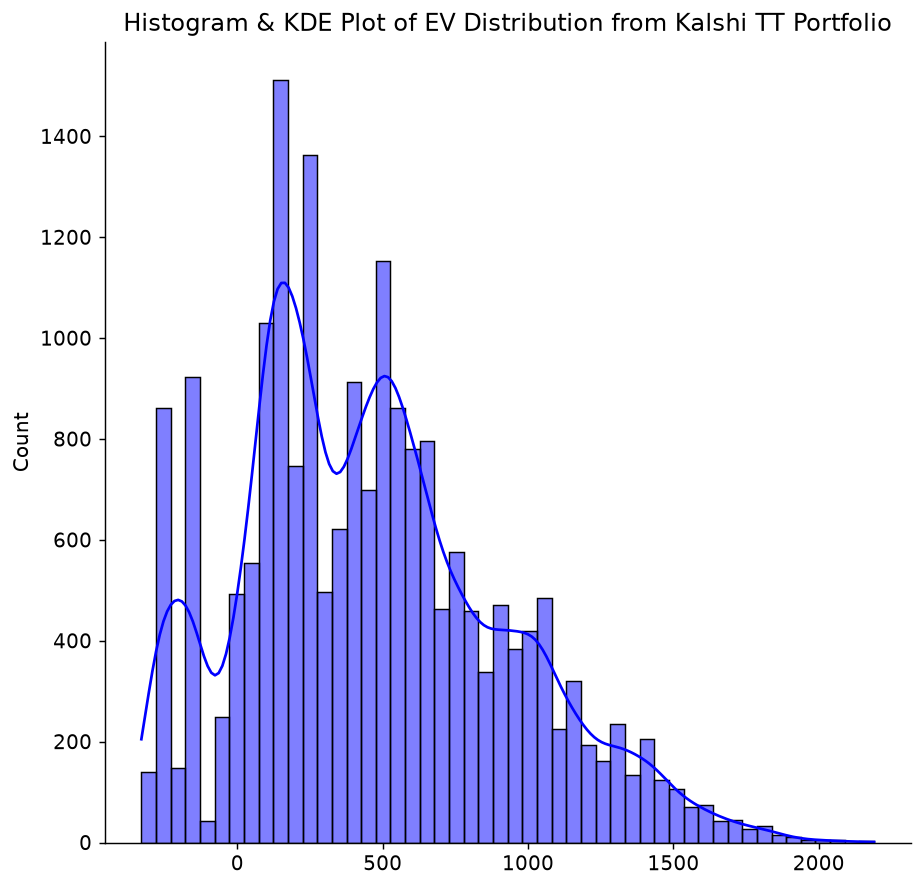

In [11]:
# Players with a broadcast round on the next TT Tuesday (scheduling conflict).
# Names must match player_information.player_name exactly.
SCHEDULING_CONFLICT = [
    'Andrey Esipenko',
    'Zhamsaran Tsydypov',
    'David Paravyan',
    'Maxim Matlakov',
    'Arseniy Nesterov'
]
# Players with an unavoidable conflict; p_participate is set to 0.
CUT_PLAYERS = [
    'Hikaru Nakamura',
    'Fabiano Caruana',
    'Wesley So',
    'Levon Aronian',
    'Leinier Dominguez Perez',
    'Javokhir Sindarov',
    'Nodirbek Abdusattorov',
    'Nodirbek Yakubboev',
    'Shamsiddin Vokhidov',
    'Mukhiddin Madaminov',
    'Christopher Yoo',
    'Grigoriy Oparin',
]
KEEP_PLAYERS = []
_df_raw, p_participate, app_counts = load_and_prepare(
    scheduling_conflict=SCHEDULING_CONFLICT,
    cut_players=CUT_PLAYERS,
    keep_players=KEEP_PLAYERS
)
players, p_play, hist_pcts, hist_wts = build_player_pool_score(_df_raw, p_participate, app_counts)
portfolio = build_portfolio(df_tt, players, PLAYER_TO_USERNAME)
pnl = run_portfolio_mc_score(players, p_play, hist_pcts, hist_wts, portfolio, n_sims=20_000)
pnl_summary(pnl)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
sns.histplot(x=pnl, kde=True, ax=ax, color='blue', bins=50)
ax.set_title('Histogram & KDE Plot of EV Distribution from Kalshi TT Portfolio')
plt.show()
plt.close(fig)

In [12]:
df_cands = df[df['ROI'] > 1.0].copy()
df_cands['n_int'] = df_cands['n'].apply(lambda x: 1 if str(x) == '21' else int(x))

df_cands_fmt = (
    df_cands
    .drop(columns=['n'])
    .rename(columns={'Player Name': 'marketTitle', 'Side': 'position', 'n_int': 'n'})
    .copy()
)
df_cands_fmt['position'] = df_cands_fmt['position'].str.title()
df_cands_fmt['volume']   = 1.0
df_cands_fmt['cost']     = df_cands_fmt['Order Price']

portfolio_cands = build_portfolio(df_cands_fmt, players, PLAYER_TO_USERNAME)

print("Running payoff matrix simulation (50k sims)...")
payoff_matrix, cost_per_share = run_payoff_matrix(
    players, p_play, hist_pcts, hist_wts,
    portfolio_cands, n_sims=50_000,
)

print("\nOptimising Kelly allocation...")
opt_shares, opt_result = portfolio_kelly(
    payoff_matrix, cost_per_share,
    bankroll=BANKROLL, kelly_fraction=KELLY_MULT,
)

df_cands['opt_shares'] = opt_shares
df_cands['opt_cost']   = opt_shares * df_cands['Order Price']
df_cands['opt_ev']     = opt_shares * df_cands['EV']
df_cands['opt_edge']   = df_cands['opt_ev'] - df_cands['opt_cost']

df_opt = df_cands[df_cands['opt_shares'] > 0].copy()
total_cost_opt = df_opt['opt_cost'].sum()
total_ev_opt   = df_opt['opt_ev'].sum()
print(f"\nPortfolio Kelly  |  Exposure ${total_cost_opt:.0f} ({total_cost_opt/BANKROLL*100:.1f}%)  |  "
      f"Expected edge ${total_ev_opt - total_cost_opt:.2f}  |  ROI {(total_ev_opt/total_cost_opt - 1)*100:.1f}%\n")

df_opt[['Market Title', 'Side', 'ROI', 'Order Price', 'EV', 'opt_shares', 'opt_cost', 'opt_edge']]\
    .sort_values('opt_shares', ascending=False)\
    .style.format({'Order Price': '{:.3f}', 'EV': '{:.3f}',
                   'opt_cost': '${:.2f}', 'opt_edge': '${:.2f}'})

Running payoff matrix simulation (50k sims)...
   10,000 / 50,000  (4.4s)
   20,000 / 50,000  (9.1s)
   30,000 / 50,000  (13.7s)
   40,000 / 50,000  (18.2s)
   50,000 / 50,000  (22.6s)

Optimising Kelly allocation...
Converged: True  |  Exposure $1000.00 (50.0% of bankroll)  |  E[log-return]: 0.7612

Portfolio Kelly  |  Exposure $1000 (50.0%)  |  Expected edge $308.22  |  ROI 30.8%



,Market Title,Side,ROI,Order Price,EV,opt_shares,opt_cost,opt_edge
110,"Will Sina Movahed win the Titled Tuesday weekly chess competition, originally scheduled for Jul 28, 2026 at 11:00am EDT?",YES,1.305000,0.064,0.083,13057,$834.97,$254.74
1217,"Will Jan-Krzysztof Duda finish top 5 in the Titled Tuesday chess competition on Jul 28, 2026?",YES,1.378000,0.159,0.219,283,$44.98,$16.99
1092,"Will Parham Maghsoodloo finish top 5 in the Titled Tuesday chess competition on Jul 28, 2026?",YES,1.348000,0.127,0.172,214,$27.26,$9.50
908,"Will Aleksei Sarana finish top 3 in the Titled Tuesday chess competition on Jul 28, 2026?",YES,1.365000,0.148,0.203,191,$28.35,$10.36
856,"Will Denis Lazavik finish top 3 in the Titled Tuesday chess competition on Jul 28, 2026?",YES,1.268000,0.169,0.215,90,$15.25,$4.09
803,"Will Hans Niemann finish top 3 in the Titled Tuesday chess competition on Jul 28, 2026?",YES,1.210000,0.096,0.116,77,$7.37,$1.55
1298,"Will Denis Lazavik finish top 5 in the Titled Tuesday chess competition on Jul 28, 2026?",YES,1.267000,0.242,0.307,57,$13.82,$3.70
1754,"Will Haik Martirosyan finish top 8 in the Titled Tuesday chess competition on Jul 28, 2026?",YES,1.231000,0.127,0.157,53,$6.75,$1.56
1182,"Will Jeffery Xiong finish top 5 in the Titled Tuesday chess competition on Jul 28, 2026?",YES,1.227000,0.148,0.182,42,$6.23,$1.42
1397,"Will Arjun Erigaisi finish top 5 in the Titled Tuesday chess competition on Jul 28, 2026?",YES,1.287000,0.169,0.218,39,$6.61,$1.90


In [13]:
# ── A: Recommended additional buys to reach Kelly-optimal sizing ──────────────
# Compares the portfolio Kelly target (opt_shares) for each position against
# shares already held in df_tt, then recommends the difference.
# Positions not yet held at all are treated as 0 shares held.

# Sum existing shares per (player_name, n, side) across all df_tt rows
held = (
    df_tt
    .assign(side_up=df_tt['position'].str.upper())
    .groupby(['marketTitle', 'n', 'side_up'])['volume']
    .sum()
)  # MultiIndex Series: (marketTitle, n, side_up) -> total shares held

def shares_held(player_name, n_int, side):
    try:
        return held.loc[(player_name, n_int, side)]
    except KeyError:
        return 0.0

df_buys = df_opt.copy()
df_buys['held']              = df_buys.apply(lambda r: shares_held(r['Player Name'], r['n_int'], r['Side']), axis=1)
df_buys['additional_shares'] = (df_buys['opt_shares'] - df_buys['held']).clip(lower=0).astype(int)
df_buys['additional_cost']   = df_buys['additional_shares'] * df_buys['Order Price']
df_buys['additional_ev']     = df_buys['additional_shares'] * df_buys['EV']
df_buys['additional_edge']   = df_buys['additional_ev'] - df_buys['additional_cost']

df_new_buys = df_buys[df_buys['additional_shares'] > 0].copy()

total_new_cost = df_new_buys['additional_cost'].sum()
total_new_ev   = df_new_buys['additional_ev'].sum()
print(f"Recommended buys  |  Additional exposure ${total_new_cost:.0f}  |  "
      f"Expected edge ${total_new_ev - total_new_cost:.2f}  |  "
      f"ROI {(total_new_ev / total_new_cost - 1)*100:.1f}%\n")

df_new_buys[['Market Title', 'Side', 'ROI', 'Order Price', 'EV', 'held', 'opt_shares', 'additional_shares', 'additional_cost', 'additional_edge']]\
    .sort_values('additional_edge', ascending=False)\
    .style.format({'Order Price': '{:.3f}', 'EV': '{:.3f}',
                   'additional_cost': '${:.2f}', 'additional_edge': '${:.2f}'})

Recommended buys  |  Additional exposure $957  |  Expected edge $295.61  |  ROI 30.9%



,Market Title,Side,ROI,Order Price,EV,held,opt_shares,additional_shares,additional_cost,additional_edge
110,"Will Sina Movahed win the Titled Tuesday weekly chess competition, originally scheduled for Jul 28, 2026 at 11:00am EDT?",YES,1.305000,0.064,0.083,0.000000,13057,13057,$834.97,$254.74
1217,"Will Jan-Krzysztof Duda finish top 5 in the Titled Tuesday chess competition on Jul 28, 2026?",YES,1.378000,0.159,0.219,55.000000,283,228,$36.23,$13.69
1092,"Will Parham Maghsoodloo finish top 5 in the Titled Tuesday chess competition on Jul 28, 2026?",YES,1.348000,0.127,0.172,0.000000,214,214,$27.26,$9.50
908,"Will Aleksei Sarana finish top 3 in the Titled Tuesday chess competition on Jul 28, 2026?",YES,1.365000,0.148,0.203,17.000000,191,174,$25.83,$9.44
856,"Will Denis Lazavik finish top 3 in the Titled Tuesday chess competition on Jul 28, 2026?",YES,1.268000,0.169,0.215,5.000000,90,85,$14.40,$3.86
1754,"Will Haik Martirosyan finish top 8 in the Titled Tuesday chess competition on Jul 28, 2026?",YES,1.231000,0.127,0.157,0.000000,53,53,$6.75,$1.56
1182,"Will Jeffery Xiong finish top 5 in the Titled Tuesday chess competition on Jul 28, 2026?",YES,1.227000,0.148,0.182,0.000000,42,42,$6.23,$1.42
1397,"Will Arjun Erigaisi finish top 5 in the Titled Tuesday chess competition on Jul 28, 2026?",YES,1.287000,0.169,0.218,10.000000,39,29,$4.91,$1.41


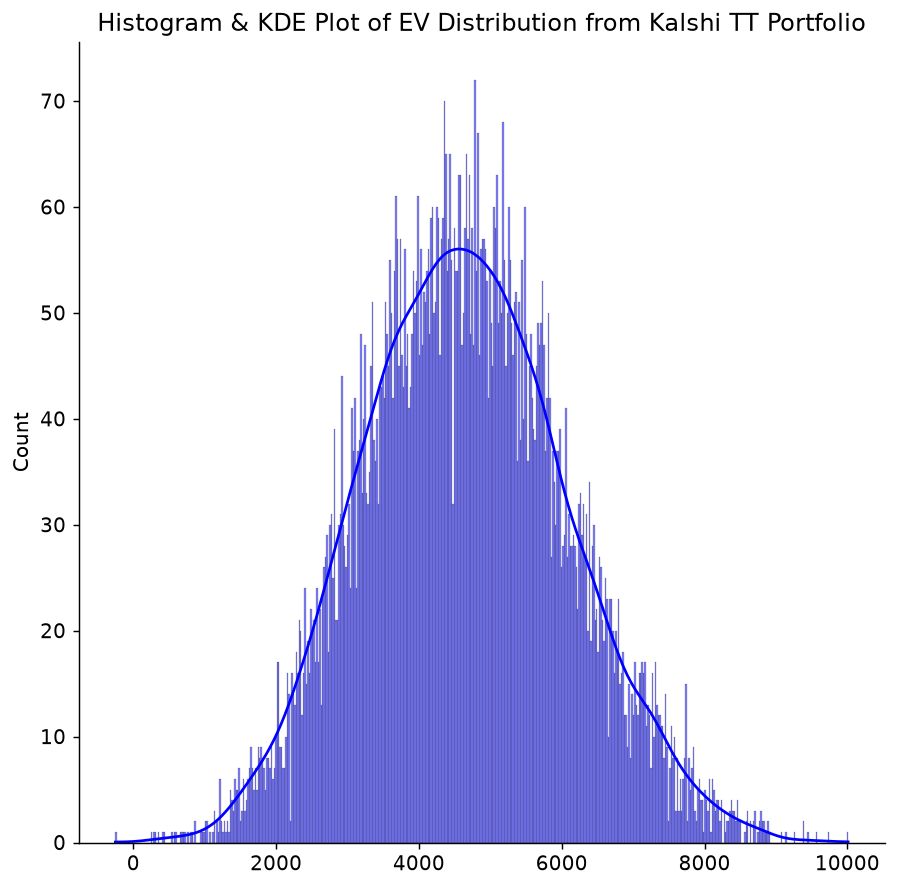

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        
sns.histplot(x=[np.sum(np.random.choice(pnl,(10,))) for _ in range (10000)], kde=True, ax=ax, color='blue', bins=500)

ax.set_title('Histogram & KDE Plot of EV Distribution from Kalshi TT Portfolio')

plt.show()
plt.close(fig)

In [6]:
def sanity_check(player_name, user=False, n=8, margin=.33):
    username = player_name
    if not user:
        username = PLAYER_TO_USERNAME[player_name]
    if username not in results.index:
        print(f'{username!r} not found in predictions (too few appearances or not in player pool).')
        return
    player_results = results.loc[username]
    fair_odds = player_results[f'P_top{n}'].item()
    if_plays = player_results[f'P_top{n}_given_play'].item()
    yes_price = fair_odds*(1-margin)
    no_price = ((1-fair_odds)*(1-margin))
    print(
        f'P({n}): {np.round(fair_odds*100,2).item()}', 
        f'YES Price: {np.round(yes_price*100,2).item()} ({margin} margin)',
        f'NO Price: {np.round(no_price*100,2).item()} ({margin} margin)',
        f'P({n}) If Plays: {np.round(if_plays*100,2).item()}',
            sep='\n')
    history = df_standings[df_standings['username']==(username)]
    display(history.tail(20))

sanity_check('Jan-Krzysztof Duda', user=False)

P(8): 27.95
YES Price: 18.73 (0.33 margin)
NO Price: 48.27 (0.33 margin)
P(8) If Plays: 38.38


,date,tournament_slug,session,rank,username,title,country,rating,score,tie_break,wins,draws,byes
275966,2026-02-03,titled-tuesday-blitz-february-03-2026-6190821,NaN,33.0,Polish_fighter3000,GM,Poland,3219,7.5,70.0,7.0,1.0,0.0
276388,2026-02-10,titled-tuesday-blitz-february-10-2026-6221327,NaN,13.0,Polish_fighter3000,GM,Poland,3181,8.5,66.0,7.0,3.0,0.0
276989,2026-02-17,titled-tuesday-blitz-february-17-2026-6221393,NaN,161.0,Polish_fighter3000,GM,Poland,3155,5.5,48.0,5.0,1.0,0.0
277264,2026-02-24,titled-tuesday-blitz-february-24-2026-6256793,NaN,2.0,Polish_fighter3000,GM,Poland,3191,9.5,66.0,9.0,1.0,0.0
277736,2026-03-03,titled-tuesday-blitz-march-03-2026-6262447,NaN,49.0,Polish_fighter3000,GM,Poland,3144,7.0,66.0,7.0,0.0,0.0
278148,2026-03-10,titled-tuesday-blitz-march-10-2026-6277141,NaN,19.0,Polish_fighter3000,GM,Poland,3140,8.0,69.0,8.0,0.0,0.0
278797,2026-03-17,titled-tuesday-blitz-march-17-2026-6282783,NaN,196.0,Polish_fighter3000,GM,Poland,3152,5.0,52.0,5.0,0.0,0.0
279067,2026-03-24,titled-tuesday-blitz-march-24-2026-6292855,NaN,4.0,Polish_fighter3000,GM,Poland,3249,9.0,70.0,8.0,2.0,0.0
279492,2026-03-31,titled-tuesday-blitz-march-31-2026-6322539,NaN,1.0,Polish_fighter3000,GM,Poland,3265,9.0,78.0,7.0,4.0,0.0
280102,2026-04-14,titled-tuesday-blitz-april-14-2026-6362193,NaN,10.0,Polish_fighter3000,GM,Poland,3281,8.0,72.0,8.0,0.0,0.0
